<Axes: >

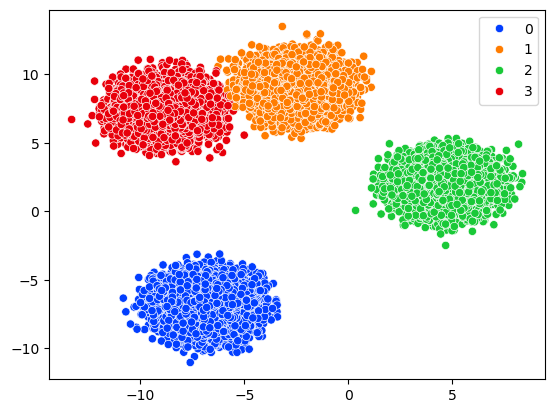

In [29]:
import seaborn as sns 
from sklearn.datasets import make_blobs  #
X ,y = make_blobs(   # y is labels(cluster id )
    n_samples=50_000,
    n_features=2,
    centers=4,  # number of  true clusters 
    random_state=42,)

# K mean 

from sklearn.cluster import KMeans

k = 4 

Kmean = KMeans(
    n_clusters=4,
    init='k-means++', # initiatiese the centroid 
    random_state=42

)

labels = Kmean.fit_predict(X)  

sns.scatterplot(x=X[:,0],y=X[:,1],hue=labels,palette="bright") 


### How to choose a K vale 
- elbow 
- silhouette score

In [30]:
from sklearn.cluster import KMeans

In [31]:
# Elbow methods 

wcss = [ ]

for k  in range(1,30):
    kmean = KMeans(n_clusters=k)
    kmean.fit_predict(X)
    wcss.append(kmean.inertia_)

<Axes: >

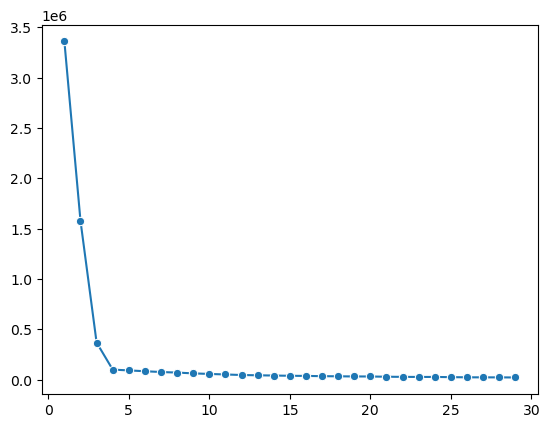

In [32]:
sns.lineplot(x=range(1, 30), y=wcss, marker='o')

automatic method of finding k use kneed module

In [33]:
# %pip install kneed

from kneed import KneeLocator

In [34]:
knee  =KneeLocator(range(1,30 ), wcss, curve='convex',direction='decreasing')

In [35]:
print("knee value :-",knee.elbow)

knee value :- 4


### Silhouette Score 

In [36]:
from sklearn.metrics import silhouette_score

In [40]:
X ,y = make_blobs(   # y is labels(cluster id )
    n_samples=10_000,
    n_features=2,
    centers=4,  # number of  true clusters 
    random_state=42,)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
ss = []
for k  in range(2,30):  # always start with two
    kmean = KMeans(n_clusters=k)
    labels = kmean.fit_predict(X_scaled)
    score = silhouette_score(X_scaled,labels)

    ss.append(score)

<Axes: >

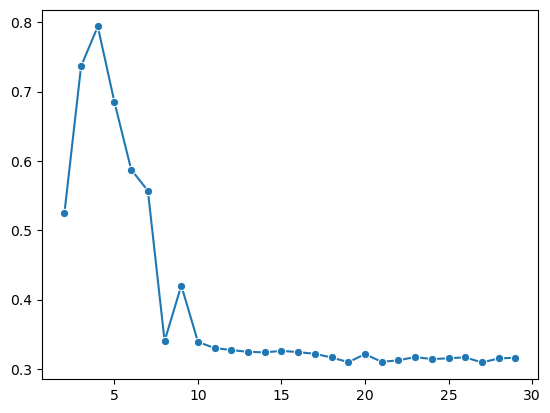

In [44]:
sns.lineplot(x=range(2,30),y=ss,marker="o")